# Pitcher IP Calibration Evaluation

Compare pitcher IP distributions **before** and **after** isotonic regression calibration.
Train the playing-time model on 2015–2023, predict for 2024, and check against phase 1 target ranges.

**Phase 1 targets** (from actual 2019–2024 excl. 2020):
- Count (IP > 0): 724–909
- Mean IP: 46–54
- Median IP: 32–38
- Total pool IP: 39,000–43,000

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from fantasy_baseball_manager.db.connection import create_connection
from fantasy_baseball_manager.db.pool import SingleConnectionProvider
from fantasy_baseball_manager.features import SqliteDatasetAssembler
from fantasy_baseball_manager.models.playing_time.model import PlayingTimeModel
from fantasy_baseball_manager.models.protocols import ModelConfig

# Use absolute path to main repo's data dir (worktree doesn't have data/)
DATA_DIR = Path("/Users/edward/Projects/fbm/data")
conn = create_connection(DATA_DIR / "fbm.db")
assembler = SqliteDatasetAssembler(
    SingleConnectionProvider(conn),
    statcast_path=DATA_DIR / "statcast.db",
)
model = PlayingTimeModel(assembler=assembler)

TRAIN_SEASONS = list(range(2015, 2024))  # 2015–2023
PREDICT_SEASONS = [2023]  # predict 2024 (max+1)

# Phase 1 target ranges
TARGETS = {
    "count_ip_gt0": (724, 909),
    "mean_ip": (46, 54),
    "median_ip": (32, 38),
    "total_pool_ip": (39_000, 43_000),
}

print(f"Training seasons: {TRAIN_SEASONS}")
print(f"Predicting season: {max(PREDICT_SEASONS) + 1}")

Training seasons: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Predicting season: 2024


## Train: calibrated vs uncalibrated

In [2]:
tmp_uncal = tempfile.mkdtemp(prefix="pt_uncal_")
tmp_cal = tempfile.mkdtemp(prefix="pt_cal_")

# Train WITHOUT calibration
train_uncal = ModelConfig(
    data_dir=str(DATA_DIR),
    artifacts_dir=tmp_uncal,
    seasons=TRAIN_SEASONS,
    model_params={"ip_calibration": False},
)
result_uncal = model.train(train_uncal)
print("Uncalibrated training done")
print(f"  R² pitcher: {result_uncal.metrics['r_squared_pitcher']:.4f}")

# Train WITH calibration (default)
train_cal = ModelConfig(
    data_dir=str(DATA_DIR),
    artifacts_dir=tmp_cal,
    seasons=TRAIN_SEASONS,
    model_params={"ip_calibration": True},
)
result_cal = model.train(train_cal)
print("Calibrated training done")
print(f"  R² pitcher: {result_cal.metrics['r_squared_pitcher']:.4f}")

Uncalibrated training done
  R² pitcher: 0.6201


Calibrated training done
  R² pitcher: 0.6201


## Predict for 2024

In [3]:
predict_cfg_uncal = ModelConfig(
    data_dir=str(DATA_DIR),
    artifacts_dir=tmp_uncal,
    seasons=PREDICT_SEASONS,
    model_params={"ip_calibration": False},
)
pred_uncal = model.predict(predict_cfg_uncal)

predict_cfg_cal = ModelConfig(
    data_dir=str(DATA_DIR),
    artifacts_dir=tmp_cal,
    seasons=PREDICT_SEASONS,
    model_params={"ip_calibration": True},
)
pred_cal = model.predict(predict_cfg_cal)

# Also predict with target_pitcher_count = 816 (midpoint of 724–909)
predict_cfg_cal_filtered = ModelConfig(
    data_dir=str(DATA_DIR),
    artifacts_dir=tmp_cal,
    seasons=PREDICT_SEASONS,
    model_params={"ip_calibration": True, "target_pitcher_count": 816},
)
pred_cal_filtered = model.predict(predict_cfg_cal_filtered)


def to_pitcher_df(result):
    df = pd.DataFrame(result.predictions)
    return df[df["player_type"] == "pitcher"].copy()


df_uncal = to_pitcher_df(pred_uncal)
df_cal = to_pitcher_df(pred_cal)
df_cal_filtered = to_pitcher_df(pred_cal_filtered)

print(f"Uncalibrated pitchers: {len(df_uncal)}")
print(f"Calibrated pitchers:   {len(df_cal)}")
print(f"Calibrated + filtered: {len(df_cal_filtered)}")

Uncalibrated pitchers: 863
Calibrated pitchers:   863
Calibrated + filtered: 816


## Load 2024 actuals for comparison

In [4]:
actual_2024 = pd.read_sql(
    "SELECT player_id, ip FROM pitching_stats WHERE season = 2024 AND ip > 0",
    conn,
)
print(f"Actual 2024 pitchers (IP > 0): {len(actual_2024)}")
print(f"Actual 2024 mean IP:  {actual_2024['ip'].mean():.1f}")
print(f"Actual 2024 median IP: {actual_2024['ip'].median():.1f}")
print(f"Actual 2024 total IP: {actual_2024['ip'].sum():.0f}")

Actual 2024 pitchers (IP > 0): 725
Actual 2024 mean IP:  54.4
Actual 2024 median IP: 42.2
Actual 2024 total IP: 39459


## Distribution comparison table

In [5]:
def dist_metrics(df, ip_col="ip", label=""):
    ips = df[ip_col]
    pos = ips[ips > 0]
    return {
        "label": label,
        "count_total": len(df),
        "count_ip_gt0": int((ips > 0).sum()),
        "count_ip_gt30": int((ips > 30).sum()),
        "count_ip_gt60": int((ips > 60).sum()),
        "count_ip_gt100": int((ips > 100).sum()),
        "count_ip_gt150": int((ips > 150).sum()),
        "mean_ip": float(pos.mean()) if len(pos) > 0 else 0,
        "median_ip": float(pos.median()) if len(pos) > 0 else 0,
        "std_ip": float(pos.std()) if len(pos) > 0 else 0,
        "total_pool_ip": float(ips.sum()),
        "p10": float(pos.quantile(0.10)) if len(pos) > 0 else 0,
        "p25": float(pos.quantile(0.25)) if len(pos) > 0 else 0,
        "p75": float(pos.quantile(0.75)) if len(pos) > 0 else 0,
        "p90": float(pos.quantile(0.90)) if len(pos) > 0 else 0,
    }


rows = [
    dist_metrics(actual_2024, label="Actual 2024"),
    dist_metrics(df_uncal, label="Uncalibrated"),
    dist_metrics(df_cal, label="Calibrated"),
    dist_metrics(df_cal_filtered, label="Cal + filter (816)"),
]
summary = pd.DataFrame(rows).set_index("label")
summary.T

label,Actual 2024,Uncalibrated,Calibrated,Cal + filter (816)
count_total,725.000000,863.000000,863.000000,816.000000
count_ip_gt0,725.000000,813.000000,863.000000,816.000000
count_ip_gt30,430.000000,662.000000,607.000000,607.000000
count_ip_gt60,248.000000,281.000000,234.000000,234.000000
count_ip_gt100,120.000000,134.000000,128.000000,128.000000
count_ip_gt150,70.000000,27.000000,55.000000,55.000000
mean_ip,54.426759,60.584046,57.338232,59.880345
median_ip,42.200000,50.367567,50.451643,50.451643
std_ip,51.693255,37.947173,38.774283,38.358071
total_pool_ip,39459.400000,49254.829390,49482.893790,48862.361396


## Pass/fail against phase 1 targets

In [6]:
def check_targets(metrics, targets):
    results = []
    for key, (lo, hi) in targets.items():
        val = metrics[key]
        status = "PASS" if lo <= val <= hi else "FAIL"
        results.append({"metric": key, "value": f"{val:.1f}", "target": f"{lo}–{hi}", "status": status})
    return pd.DataFrame(results)


print("=== Uncalibrated ===")
m_uncal = dist_metrics(df_uncal, label="uncal")
display(check_targets(m_uncal, TARGETS))

print("\n=== Calibrated (no count filter) ===")
m_cal = dist_metrics(df_cal, label="cal")
display(check_targets(m_cal, TARGETS))

print("\n=== Calibrated + filter (816) ===")
m_cal_f = dist_metrics(df_cal_filtered, label="cal_f")
display(check_targets(m_cal_f, TARGETS))

=== Uncalibrated ===


,metric,value,target,status
0,count_ip_gt0,813.0,724–909,PASS
1,mean_ip,60.6,46–54,FAIL
2,median_ip,50.4,32–38,FAIL
3,total_pool_ip,49254.8,39000–43000,FAIL



=== Calibrated (no count filter) ===


,metric,value,target,status
0,count_ip_gt0,863.0,724–909,PASS
1,mean_ip,57.3,46–54,FAIL
2,median_ip,50.5,32–38,FAIL
3,total_pool_ip,49482.9,39000–43000,FAIL



=== Calibrated + filter (816) ===


,metric,value,target,status
0,count_ip_gt0,816.0,724–909,PASS
1,mean_ip,59.9,46–54,FAIL
2,median_ip,50.5,32–38,FAIL
3,total_pool_ip,48862.4,39000–43000,FAIL


## Rank correlation: calibrated vs uncalibrated vs actuals

In [7]:
# Merge predictions with actuals on player_id
merged_uncal = df_uncal.merge(actual_2024, on="player_id", suffixes=("_pred", "_actual"))
merged_cal = df_cal.merge(actual_2024, on="player_id", suffixes=("_pred", "_actual"))

rho_uncal, _ = spearmanr(merged_uncal["ip_pred"], merged_uncal["ip_actual"])
rho_cal, _ = spearmanr(merged_cal["ip_pred"], merged_cal["ip_actual"])

# Also rank correlation between calibrated and uncalibrated (should be very high)
merged_both = df_uncal[["player_id", "ip"]].merge(
    df_cal[["player_id", "ip"]], on="player_id", suffixes=("_uncal", "_cal")
)
rho_cal_vs_uncal, _ = spearmanr(merged_both["ip_uncal"], merged_both["ip_cal"])

print(f"Spearman ρ (uncalibrated vs actual):  {rho_uncal:.4f}")
print(f"Spearman ρ (calibrated vs actual):    {rho_cal:.4f}")
print(f"Spearman ρ (cal vs uncal):            {rho_cal_vs_uncal:.4f}")
print(f"\nRank correlation {'preserved ✓' if rho_cal >= rho_uncal - 0.005 else 'DEGRADED ✗'}")

Spearman ρ (uncalibrated vs actual):  0.6432
Spearman ρ (calibrated vs actual):    0.6407
Spearman ρ (cal vs uncal):            0.9986

Rank correlation preserved ✓


## CDF overlay plot

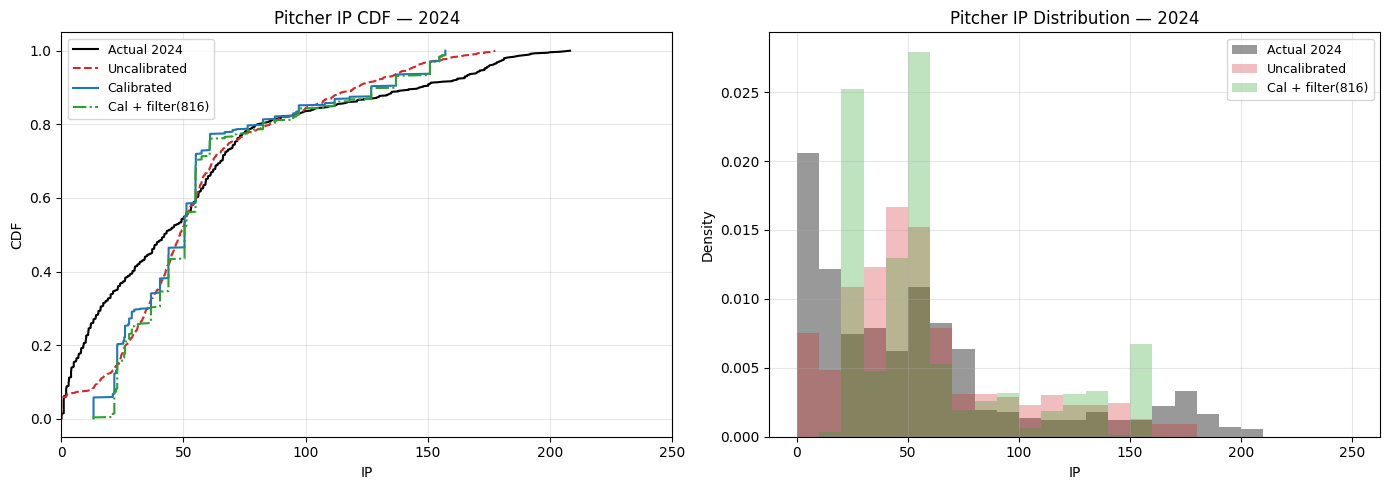

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CDF plot
ax = axes[0]
for label, ips, color, ls in [
    ("Actual 2024", actual_2024["ip"], "black", "-"),
    ("Uncalibrated", df_uncal["ip"], "tab:red", "--"),
    ("Calibrated", df_cal["ip"], "tab:blue", "-"),
    ("Cal + filter(816)", df_cal_filtered["ip"], "tab:green", "-."),
]:
    sorted_ip = np.sort(ips.values)
    cdf = np.arange(1, len(sorted_ip) + 1) / len(sorted_ip)
    ax.plot(sorted_ip, cdf, label=label, color=color, linestyle=ls, linewidth=1.5)

ax.set_xlabel("IP")
ax.set_ylabel("CDF")
ax.set_title("Pitcher IP CDF — 2024")
ax.set_xlim(0, 250)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Histogram overlay
ax2 = axes[1]
bins = np.arange(0, 260, 10)
ax2.hist(actual_2024["ip"], bins=bins, alpha=0.4, label="Actual 2024", color="black", density=True)
ax2.hist(df_uncal["ip"], bins=bins, alpha=0.3, label="Uncalibrated", color="tab:red", density=True)
ax2.hist(df_cal_filtered["ip"], bins=bins, alpha=0.3, label="Cal + filter(816)", color="tab:green", density=True)
ax2.set_xlabel("IP")
ax2.set_ylabel("Density")
ax2.set_title("Pitcher IP Distribution — 2024")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Scatter: calibrated vs uncalibrated IP

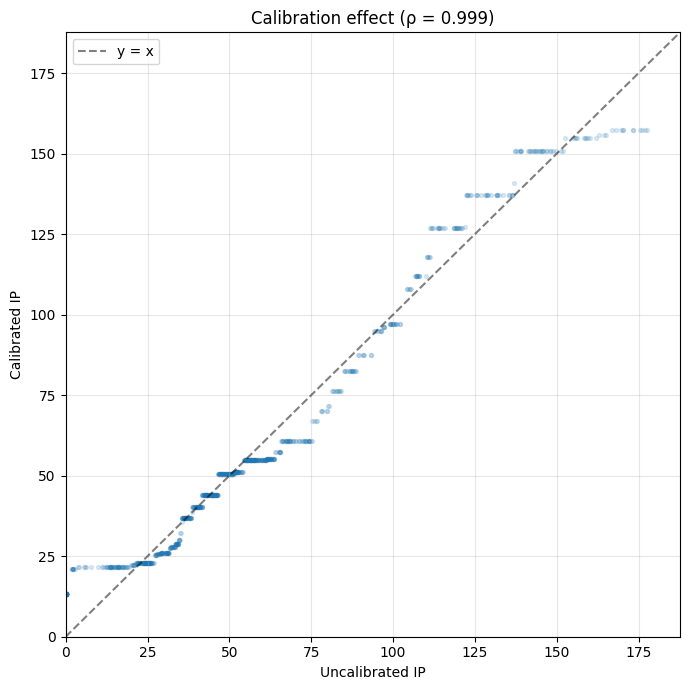

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(merged_both["ip_uncal"], merged_both["ip_cal"], alpha=0.15, s=8)
lims = [0, max(merged_both["ip_uncal"].max(), merged_both["ip_cal"].max()) + 10]
ax.plot(lims, lims, "k--", alpha=0.5, label="y = x")
ax.set_xlabel("Uncalibrated IP")
ax.set_ylabel("Calibrated IP")
ax.set_title(f"Calibration effect (ρ = {rho_cal_vs_uncal:.3f})")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Top 20 pitchers: calibrated vs uncalibrated

In [10]:
# Get player names
players = pd.read_sql(
    "SELECT id AS player_id, name_first || ' ' || name_last AS name FROM player",
    conn,
)

top20 = (
    merged_both.sort_values("ip_cal", ascending=False)
    .head(20)
    .merge(players, on="player_id", how="left")
    .merge(actual_2024.rename(columns={"ip": "ip_actual"}), on="player_id", how="left")
)
top20[["name", "ip_uncal", "ip_cal", "ip_actual"]].round(1)

,name,ip_uncal,ip_cal,ip_actual
0,Kevin Gausman,167.0,157.2,181.0
1,Aaron Nola,177.6,157.2,199.1
2,Miles Mikolas,175.4,157.2,171.2
3,Zac Gallen,169.7,157.2,148.0
4,Corbin Burnes,173.1,157.2,194.1
5,Merrill Kelly,170.3,157.2,73.2
6,Luis Castillo,170.2,157.2,175.1
7,Logan Webb,173.2,157.2,204.2
8,Chris Bassitt,175.9,157.2,171.0
9,Zack Wheeler,168.1,157.2,200.0


## Experiment: lowering the spine min_ip threshold

The spine currently requires `min_ip=10` in a prior season. Let's test what happens with lower thresholds by querying the spine directly.

In [11]:
# How many pitchers appear in the spine at different min_ip thresholds?
# The spine is built from pitching_stats in prior seasons.
# For predicting 2024, features come from seasons up to 2023.

thresholds = [0, 1, 2, 5, 10, 20]
threshold_counts = []
for t in thresholds:
    q = f"""
    SELECT COUNT(DISTINCT player_id) as n_pitchers
    FROM pitching_stats
    WHERE season = 2023 AND ip >= {t}
    """
    n = pd.read_sql(q, conn).iloc[0, 0]
    threshold_counts.append({"min_ip": t, "pitchers_in_spine_2023": n})

# Also check: how many 2024 actual pitchers had prior-season IP < 10?
q2 = """
SELECT COUNT(*) FROM pitching_stats ps2024
WHERE ps2024.season = 2024 AND ps2024.ip > 0
AND ps2024.player_id NOT IN (
    SELECT player_id FROM pitching_stats WHERE season = 2023 AND ip >= 10
)
"""
n_missing = pd.read_sql(q2, conn).iloc[0, 0]

pd.DataFrame(threshold_counts).set_index("min_ip")

,pitchers_in_spine_2023
min_ip,
0,863
1,851
2,805
5,727
10,659
20,550


In [12]:
print(f"2024 actual pitchers NOT in current spine (min_ip=10 in 2023): {n_missing}")
print(f"  out of {len(actual_2024)} total actual 2024 pitchers")
print(f"  = {n_missing / len(actual_2024) * 100:.1f}% of 2024 pitchers are missed by the spine")

# What do those missed pitchers look like?
missed = pd.read_sql(
    """
SELECT ps2024.player_id, ps2024.ip as ip_2024,
       COALESCE(ps2023.ip, 0) as ip_2023
FROM pitching_stats ps2024
LEFT JOIN pitching_stats ps2023
  ON ps2024.player_id = ps2023.player_id AND ps2023.season = 2023
WHERE ps2024.season = 2024 AND ps2024.ip > 0
AND ps2024.player_id NOT IN (
    SELECT player_id FROM pitching_stats WHERE season = 2023 AND ip >= 10
)
""",
    conn,
)

print(f"\nMissed pitchers' 2024 IP distribution:")
print(missed["ip_2024"].describe().round(1))
print(f"\nMissed pitchers' 2023 IP (0 = not in 2023 stats):")
print(missed["ip_2023"].describe().round(1))

2024 actual pitchers NOT in current spine (min_ip=10 in 2023): 205
  out of 725 total actual 2024 pitchers
  = 28.3% of 2024 pitchers are missed by the spine

Missed pitchers' 2024 IP distribution:
count    205.0
mean      25.9
std       33.8
min        0.1
25%        3.0
50%       11.1
75%       38.0
max      177.1
Name: ip_2024, dtype: float64

Missed pitchers' 2023 IP (0 = not in 2023 stats):
count    205.0
mean       1.8
std        2.7
min        0.0
25%        0.0
50%        0.0
75%        3.0
max        9.2
Name: ip_2023, dtype: float64


In [13]:
# Simulate what lowering min_ip would do to the predictions
# Use the model directly but with a patched spine filter
from fantasy_baseball_manager.features.types import SpineFilter

results_by_threshold = []
for min_ip_val in [None, 1.0, 5.0, 10.0]:
    label = f"min_ip={min_ip_val}" if min_ip_val is not None else "min_ip=None"

    # Monkey-patch the model to use a different spine filter
    # We'll do this by building feature sets manually
    _, pitching_fs = model._build_feature_sets(PREDICT_SEASONS, training=False)

    # Create new feature set with modified spine filter
    from fantasy_baseball_manager.features.types import FeatureSet

    modified_fs = FeatureSet(
        name=pitching_fs.name + f"_minip{min_ip_val}",
        features=pitching_fs.features,
        seasons=pitching_fs.seasons,
        source_filter=pitching_fs.source_filter,
        spine_filter=SpineFilter(min_ip=min_ip_val, player_type="pitcher"),
    )

    handle = assembler.get_or_materialize(modified_fs)
    n_rows = handle.row_count
    results_by_threshold.append(
        {
            "threshold": label,
            "pitchers_in_spine": n_rows,
        }
    )
    print(f"{label}: {n_rows} pitchers in prediction spine")

pd.DataFrame(results_by_threshold)

min_ip=None: 863 pitchers in prediction spine
min_ip=1.0: 851 pitchers in prediction spine
min_ip=5.0: 727 pitchers in prediction spine
min_ip=10.0: 659 pitchers in prediction spine


,threshold,pitchers_in_spine
0,min_ip=None,863
1,min_ip=1.0,851
2,min_ip=5.0,727
3,min_ip=10.0,659


## Who are the high-IP pitchers missed by the spine?

In [14]:
# High-IP pitchers in 2024 who were NOT in the min_ip=10 spine
# These are TJ rehabs, injury returns, debuts, etc.
high_ip_missed = pd.read_sql(
    """
SELECT p.name_first || ' ' || p.name_last AS name,
       ps2024.ip AS ip_2024,
       COALESCE(ps2023.ip, 0) AS ip_2023,
       COALESCE(ps2022.ip, 0) AS ip_2022,
       COALESCE(ps2021.ip, 0) AS ip_2021
FROM pitching_stats ps2024
JOIN player p ON p.id = ps2024.player_id
LEFT JOIN pitching_stats ps2023
  ON ps2024.player_id = ps2023.player_id AND ps2023.season = 2023
LEFT JOIN pitching_stats ps2022
  ON ps2024.player_id = ps2022.player_id AND ps2022.season = 2022
LEFT JOIN pitching_stats ps2021
  ON ps2024.player_id = ps2021.player_id AND ps2021.season = 2021
WHERE ps2024.season = 2024 AND ps2024.ip > 0
AND ps2024.player_id NOT IN (
    SELECT player_id FROM pitching_stats WHERE season = 2023 AND ip >= 10
)
ORDER BY ps2024.ip DESC
""",
    conn,
)

print(f"Top 30 missed pitchers by 2024 IP:")
high_ip_missed.head(30)

Top 30 missed pitchers by 2024 IP:


,name,ip_2024,ip_2023,ip_2022,ip_2021
0,Erick Fedde,177.1,0.0,127.0,133.1
1,Shota Imanaga,173.1,0.0,0.0,0.0
2,Luis Gil,151.2,0.0,4.0,29.1
3,Mitch Spence,151.1,0.0,0.0,0.0
4,Frankie Montas,150.2,1.1,144.1,187.0
5,Simeon Woods Richardson,133.2,4.2,5.0,0.0
6,Albert Suárez,133.2,0.0,0.0,0.0
7,Jared Jones,121.2,0.0,0.0,0.0
8,Casey Mize,102.1,0.0,10.0,150.1
9,Yoshinobu Yamamoto,90.0,0.0,0.0,0.0


In [15]:
# How many of these had significant IP in 2021 or 2022? (TJ / long injury returns)
tj_candidates = high_ip_missed[
    (high_ip_missed["ip_2023"] < 10) & ((high_ip_missed["ip_2022"] >= 50) | (high_ip_missed["ip_2021"] >= 50))
]
print(f"\nLikely TJ/injury returns (0 in 2023, 50+ in 2021 or 2022): {len(tj_candidates)}")
print(f"Their combined 2024 IP: {tj_candidates['ip_2024'].sum():.0f}")
tj_candidates


Likely TJ/injury returns (0 in 2023, 50+ in 2021 or 2022): 32
Their combined 2024 IP: 1296


,name,ip_2024,ip_2023,ip_2022,ip_2021
0,Erick Fedde,177.1,0.0,127.0,133.1
4,Frankie Montas,150.2,1.1,144.1,187.0
8,Casey Mize,102.1,0.0,10.0,150.1
10,Chris Paddack,88.1,5.0,22.1,108.1
13,Walker Buehler,75.1,0.0,65.0,207.2
14,Joe Ross,74.0,0.0,0.0,108.0
16,Hunter Strickland,73.1,0.0,62.1,58.2
21,Daniel Hudson,63.0,3.0,24.1,51.2
33,Edwin Díaz,53.2,0.0,62.0,62.2
35,Anthony Bender,53.0,0.0,19.1,61.1


In [16]:
# Check across multiple seasons: how common is this pattern?
# Pitchers who missed a full year but had 100+ IP two years prior
for predict_year in [2019, 2021, 2022, 2023, 2024]:
    prior = predict_year - 1
    two_back = predict_year - 2
    q = f"""
    SELECT COUNT(*) FROM pitching_stats ps_curr
    JOIN pitching_stats ps_old
      ON ps_curr.player_id = ps_old.player_id AND ps_old.season = {two_back}
    WHERE ps_curr.season = {predict_year} AND ps_curr.ip >= 100
    AND ps_old.ip >= 100
    AND ps_curr.player_id NOT IN (
        SELECT player_id FROM pitching_stats WHERE season = {prior} AND ip >= 10
    )
    """
    n = pd.read_sql(q, conn).iloc[0, 0]
    print(f"{predict_year}: {n} pitchers with 100+ IP missed by spine (had 100+ IP in {two_back}, <10 in {prior})")

2019: 0 pitchers with 100+ IP missed by spine (had 100+ IP in 2017, <10 in 2018)
2021: 3 pitchers with 100+ IP missed by spine (had 100+ IP in 2019, <10 in 2020)
2022: 0 pitchers with 100+ IP missed by spine (had 100+ IP in 2020, <10 in 2021)
2023: 1 pitchers with 100+ IP missed by spine (had 100+ IP in 2021, <10 in 2022)
2024: 2 pitchers with 100+ IP missed by spine (had 100+ IP in 2022, <10 in 2023)


## Full train/predict with min_ip removed

Retrain the model with no spine filter and compare against targets.

In [17]:
tmp_nofilter = tempfile.mkdtemp(prefix="pt_nofilter_")

# Train with no min_ip filter + calibration
train_nofilter = ModelConfig(
    data_dir=str(DATA_DIR),
    artifacts_dir=tmp_nofilter,
    seasons=TRAIN_SEASONS,
    model_params={"ip_calibration": True},  # min_ip defaults to None now
)
result_nofilter = model.train(train_nofilter)
print(f"R² pitcher (no filter): {result_nofilter.metrics['r_squared_pitcher']:.4f}")

# Predict — raw (all pitchers)
pred_nofilter = model.predict(
    ModelConfig(
        data_dir=str(DATA_DIR),
        artifacts_dir=tmp_nofilter,
        seasons=PREDICT_SEASONS,
        model_params={"ip_calibration": True},
    )
)

# Predict — with target_pitcher_count = 816
pred_nofilter_816 = model.predict(
    ModelConfig(
        data_dir=str(DATA_DIR),
        artifacts_dir=tmp_nofilter,
        seasons=PREDICT_SEASONS,
        model_params={"ip_calibration": True, "target_pitcher_count": 816},
    )
)

df_nf = to_pitcher_df(pred_nofilter)
df_nf_816 = to_pitcher_df(pred_nofilter_816)

print(f"\nNo filter, all pitchers: {len(df_nf)}")
print(f"No filter, top 816:     {len(df_nf_816)}")

R² pitcher (no filter): 0.6201

No filter, all pitchers: 863
No filter, top 816:     816


In [18]:
# Compare all variants against targets
rows_compare = [
    dist_metrics(actual_2024, label="Actual 2024"),
    dist_metrics(df_uncal, label="Old (min_ip=10, no cal)"),
    dist_metrics(df_cal, label="Old (min_ip=10, cal)"),
    dist_metrics(df_nf, label="New (no filter, cal)"),
    dist_metrics(df_nf_816, label="New (no filter, cal, top 816)"),
]
compare_df = pd.DataFrame(rows_compare).set_index("label")
compare_df.T

label,Actual 2024,"Old (min_ip=10, no cal)","Old (min_ip=10, cal)","New (no filter, cal)","New (no filter, cal, top 816)"
count_total,725.000000,863.000000,863.000000,863.000000,816.000000
count_ip_gt0,725.000000,813.000000,863.000000,863.000000,816.000000
count_ip_gt30,430.000000,662.000000,607.000000,607.000000,607.000000
count_ip_gt60,248.000000,281.000000,234.000000,234.000000,234.000000
count_ip_gt100,120.000000,134.000000,128.000000,128.000000,128.000000
count_ip_gt150,70.000000,27.000000,55.000000,55.000000,55.000000
mean_ip,54.426759,60.584046,57.338232,57.338232,59.880345
median_ip,42.200000,50.367567,50.451643,50.451643,50.451643
std_ip,51.693255,37.947173,38.774283,38.774283,38.358071
total_pool_ip,39459.400000,49254.829390,49482.893790,49482.893790,48862.361396


In [19]:
# Pass/fail for each variant
for label, df in [
    ("New (no filter, cal)", df_nf),
    ("New (no filter, cal, top 816)", df_nf_816),
]:
    print(f"\n=== {label} ===")
    m = dist_metrics(df, label=label)
    display(check_targets(m, TARGETS))


=== New (no filter, cal) ===


,metric,value,target,status
0,count_ip_gt0,863.0,724–909,PASS
1,mean_ip,57.3,46–54,FAIL
2,median_ip,50.5,32–38,FAIL
3,total_pool_ip,49482.9,39000–43000,FAIL



=== New (no filter, cal, top 816) ===


,metric,value,target,status
0,count_ip_gt0,816.0,724–909,PASS
1,mean_ip,59.9,46–54,FAIL
2,median_ip,50.5,32–38,FAIL
3,total_pool_ip,48862.4,39000–43000,FAIL


Spearman ρ (no filter, cal vs actual):    0.6407
Spearman ρ (old min_ip=10, cal vs actual): 0.6407
Spearman ρ (old min_ip=10, no cal vs actual): 0.6432


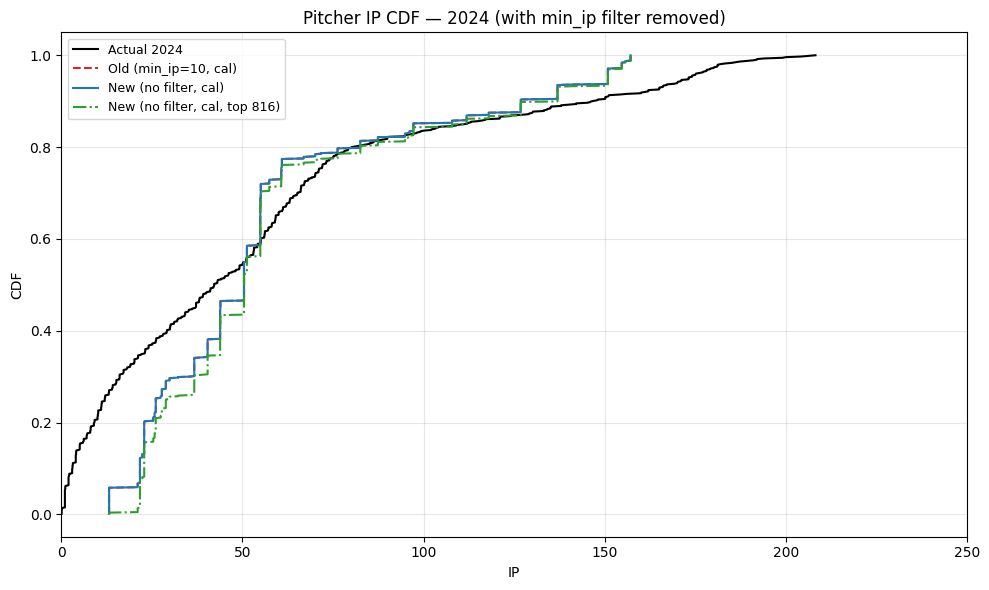

In [20]:
# Rank correlation for new variants
merged_nf = df_nf.merge(actual_2024, on="player_id", suffixes=("_pred", "_actual"))
rho_nf, _ = spearmanr(merged_nf["ip_pred"], merged_nf["ip_actual"])
print(f"Spearman ρ (no filter, cal vs actual):    {rho_nf:.4f}")
print(f"Spearman ρ (old min_ip=10, cal vs actual): {rho_cal:.4f}")
print(f"Spearman ρ (old min_ip=10, no cal vs actual): {rho_uncal:.4f}")

# CDF overlay: new variants vs actual
fig, ax = plt.subplots(figsize=(10, 6))
for label, ips, color, ls in [
    ("Actual 2024", actual_2024["ip"], "black", "-"),
    ("Old (min_ip=10, cal)", df_cal["ip"], "tab:red", "--"),
    ("New (no filter, cal)", df_nf["ip"], "tab:blue", "-"),
    ("New (no filter, cal, top 816)", df_nf_816["ip"], "tab:green", "-."),
]:
    sorted_ip = np.sort(ips.values)
    cdf = np.arange(1, len(sorted_ip) + 1) / len(sorted_ip)
    ax.plot(sorted_ip, cdf, label=label, color=color, linestyle=ls, linewidth=1.5)

ax.set_xlabel("IP")
ax.set_ylabel("CDF")
ax.set_title("Pitcher IP CDF — 2024 (with min_ip filter removed)")
ax.set_xlim(0, 250)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Who are the TJ/injury return pitchers that are now captured?
# Check if the previously-missed big names appear in predictions
missed_ids = set(high_ip_missed.head(15).merge(players, left_on="name", right_on="name")["player_id"])
nf_by_id = df_nf.set_index("player_id")

print("Previously missed pitchers now in predictions:\n")
for _, row in high_ip_missed.head(15).iterrows():
    pid = players[players["name"] == row["name"]]["player_id"].values
    if len(pid) > 0 and pid[0] in nf_by_id.index:
        pred_ip = nf_by_id.loc[pid[0], "ip"]
        print(f"  {row['name']:25s}  predicted: {pred_ip:6.1f}  actual: {row['ip_2024']:6.1f}")
    else:
        print(f"  {row['name']:25s}  NOT in predictions (no prior-season stats at all)")

Previously missed pitchers now in predictions:

  Erick Fedde                NOT in predictions (no prior-season stats at all)
  Shota Imanaga              NOT in predictions (no prior-season stats at all)
  Luis Gil                   NOT in predictions (no prior-season stats at all)
  Mitch Spence               NOT in predictions (no prior-season stats at all)
  Frankie Montas             predicted:  137.0  actual:  150.2
  Simeon Woods Richardson    predicted:   50.5  actual:  133.2
  Albert Suárez              NOT in predictions (no prior-season stats at all)
  Jared Jones                NOT in predictions (no prior-season stats at all)
  Casey Mize                 NOT in predictions (no prior-season stats at all)
  Yoshinobu Yamamoto         NOT in predictions (no prior-season stats at all)
  Chris Paddack              predicted:   70.1  actual:   88.1
  Shane Baz                  NOT in predictions (no prior-season stats at all)
  Cade Smith                 NOT in predictions (no 

## Projection-based spine (steamer ∪ zips)

Use the external projection systems as the pitcher universe instead of prior-season stats.
This captures TJ returns, NPB/KBO imports, and top prospects who have steamer/zips projections
but no recent MLB stats.

In [22]:
# Build projection-based spine: steamer ∪ zips pitcher IDs for 2024
from fantasy_baseball_manager.repos.projection_repo import SqliteProjectionRepo

projection_repo = SqliteProjectionRepo(SingleConnectionProvider(conn))

# Create model with projection_repo
model_proj = PlayingTimeModel(assembler=assembler, projection_repo=projection_repo)

# Check how many pitcher IDs are in steamer ∪ zips for 2024
proj_ids = model_proj._get_projection_pitcher_ids(2024)
print(f"Steamer ∪ ZiPS pitcher IDs for 2024: {len(proj_ids) if proj_ids else 0}")

# How many of these are NOT in the stats-based spine?
stats_spine_ids = set(
    pd.read_sql(
        "SELECT DISTINCT player_id FROM pitching_stats WHERE season = 2023",
        conn,
    )["player_id"]
)
proj_only = set(proj_ids) - stats_spine_ids if proj_ids else set()
print(f"Projection-only pitchers (no 2023 stats): {len(proj_only)}")

# How many of the previously-missed pitchers are now captured?
missed_names_df = high_ip_missed.head(15).merge(players, on="name")
missed_name_ids = set(missed_names_df["player_id"].values)
captured = missed_name_ids & set(proj_ids) if proj_ids else set()
print(f"\nOf top 15 missed pitchers, now captured by projection spine: {len(captured)}")
for _, row in missed_names_df.iterrows():
    pid = row["player_id"]
    in_proj = "✓" if proj_ids and pid in set(proj_ids) else "✗"
    print(f"  {in_proj} {row['name']:25s}  actual 2024 IP: {row['ip_2024']:6.1f}")

Steamer ∪ ZiPS pitcher IDs for 2024: 1632
Projection-only pitchers (no 2023 stats): 829

Of top 15 missed pitchers, now captured by projection spine: 15
  ✓ Erick Fedde                actual 2024 IP:  177.1
  ✓ Shota Imanaga              actual 2024 IP:  173.1
  ✓ Luis Gil                   actual 2024 IP:  151.2
  ✓ Mitch Spence               actual 2024 IP:  151.1
  ✓ Frankie Montas             actual 2024 IP:  150.2
  ✓ Simeon Woods Richardson    actual 2024 IP:  133.2
  ✓ Albert Suárez              actual 2024 IP:  133.2
  ✓ Jared Jones                actual 2024 IP:  121.2
  ✓ Casey Mize                 actual 2024 IP:  102.1
  ✓ Yoshinobu Yamamoto         actual 2024 IP:   90.0
  ✓ Chris Paddack              actual 2024 IP:   88.1
  ✓ Shane Baz                  actual 2024 IP:   79.1
  ✓ Cade Smith                 actual 2024 IP:   75.1
  ✓ Walker Buehler             actual 2024 IP:   75.1
  ✓ Joe Ross                   actual 2024 IP:   74.0


In [23]:
# Train with calibration, then predict using projection-based spine
# model_proj now uses consensus_ip fallback for lagless pitchers
tmp_proj = tempfile.mkdtemp(prefix="pt_proj_")

# Training still uses stats-based spine (no projection spine for training)
train_proj = ModelConfig(
    data_dir=str(DATA_DIR),
    artifacts_dir=tmp_proj,
    seasons=TRAIN_SEASONS,
    model_params={"ip_calibration": True},
)
result_proj = model_proj.train(train_proj)
print(f"R² pitcher: {result_proj.metrics['r_squared_pitcher']:.4f}")

# Predict using projection-based spine (model_proj has projection_repo)
pred_proj = model_proj.predict(
    ModelConfig(
        data_dir=str(DATA_DIR),
        artifacts_dir=tmp_proj,
        seasons=PREDICT_SEASONS,
        model_params={"ip_calibration": True},
    )
)

# Also with target_pitcher_count = 725 (matching actual count)
pred_proj_725 = model_proj.predict(
    ModelConfig(
        data_dir=str(DATA_DIR),
        artifacts_dir=tmp_proj,
        seasons=PREDICT_SEASONS,
        model_params={"ip_calibration": True, "target_pitcher_count": 725},
    )
)

df_proj = to_pitcher_df(pred_proj)
df_proj_725 = to_pitcher_df(pred_proj_725)

print(f"\nProjection spine, all pitchers: {len(df_proj)}")
print(f"Projection spine, top 725:     {len(df_proj_725)}")

R² pitcher: 0.6201



Projection spine, all pitchers: 1632
Projection spine, top 725:     725


In [24]:
# Compare all variants including projection-based spine with consensus fallback
rows_final = [
    dist_metrics(actual_2024, label="Actual 2024"),
    dist_metrics(df_nf, label="Stats spine (no filter, cal)"),
    dist_metrics(df_proj, label="Proj spine (cal)"),
    dist_metrics(df_proj_725, label="Proj spine (cal, top 725)"),
]
final_df = pd.DataFrame(rows_final).set_index("label")
final_df.T

label,Actual 2024,"Stats spine (no filter, cal)",Proj spine (cal),"Proj spine (cal, top 725)"
count_total,725.000000,863.000000,1632.000000,725.000000
count_ip_gt0,725.000000,863.000000,1632.000000,725.000000
count_ip_gt30,430.000000,607.000000,802.000000,725.000000
count_ip_gt60,248.000000,234.000000,272.000000,272.000000
count_ip_gt100,120.000000,128.000000,139.000000,139.000000
count_ip_gt150,70.000000,55.000000,58.000000,58.000000
mean_ip,54.426759,57.338232,43.927976,71.156206
median_ip,42.200000,50.451643,28.857971,54.938035
std_ip,51.693255,38.774283,34.106156,35.160680
total_pool_ip,39459.400000,49482.893790,71690.457621,51588.249591


In [25]:
# Pass/fail for projection-based spine variants
for label, df in [
    ("Proj spine (cal)", df_proj),
    ("Proj spine (cal, top 725)", df_proj_725),
]:
    print(f"\n=== {label} ===")
    m = dist_metrics(df, label=label)
    display(check_targets(m, TARGETS))

# Rank correlation
merged_proj = df_proj.merge(actual_2024, on="player_id", suffixes=("_pred", "_actual"))
rho_proj, _ = spearmanr(merged_proj["ip_pred"], merged_proj["ip_actual"])

merged_proj_725 = df_proj_725.merge(actual_2024, on="player_id", suffixes=("_pred", "_actual"))
rho_proj_725, _ = spearmanr(merged_proj_725["ip_pred"], merged_proj_725["ip_actual"])

print(f"\nSpearman ρ (proj spine, cal vs actual):       {rho_proj:.4f}")
print(f"Spearman ρ (proj spine, top 725 vs actual):   {rho_proj_725:.4f}")
print(f"Spearman ρ (stats spine, cal vs actual):      {rho_cal:.4f}")
print(f"Rank correlation {'preserved ✓' if rho_proj >= rho_cal - 0.005 else 'DEGRADED ✗'}")


=== Proj spine (cal) ===


,metric,value,target,status
0,count_ip_gt0,1632.0,724–909,FAIL
1,mean_ip,43.9,46–54,FAIL
2,median_ip,28.9,32–38,FAIL
3,total_pool_ip,71690.5,39000–43000,FAIL



=== Proj spine (cal, top 725) ===


,metric,value,target,status
0,count_ip_gt0,725.0,724–909,PASS
1,mean_ip,71.2,46–54,FAIL
2,median_ip,54.9,32–38,FAIL
3,total_pool_ip,51588.2,39000–43000,FAIL



Spearman ρ (proj spine, cal vs actual):       0.6094
Spearman ρ (proj spine, top 725 vs actual):   0.5591
Spearman ρ (stats spine, cal vs actual):      0.6407
Rank correlation DEGRADED ✗


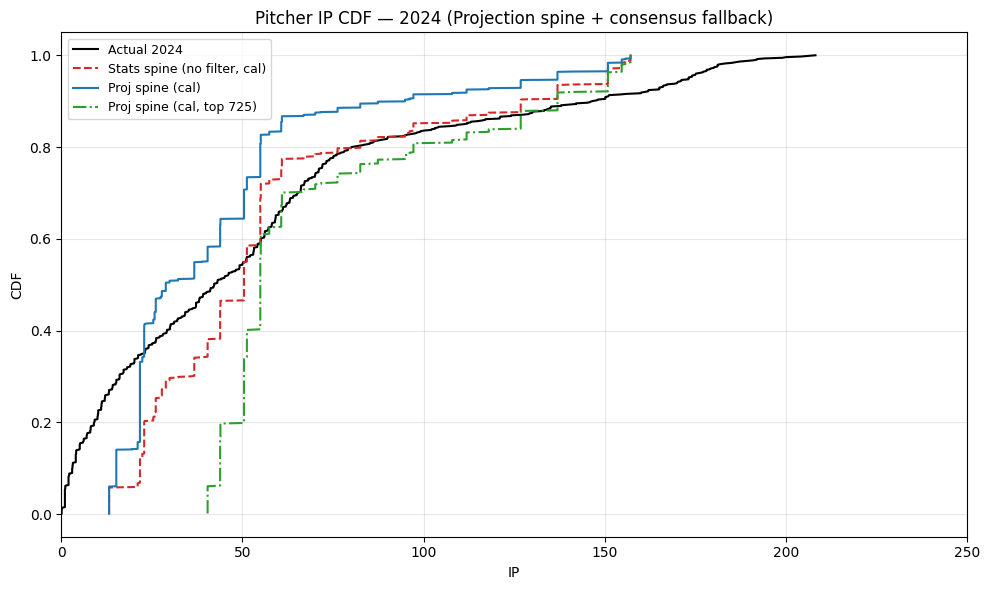

In [26]:
# CDF overlay: projection spine vs stats spine vs actual
fig, ax = plt.subplots(figsize=(10, 6))
for label, ips, color, ls in [
    ("Actual 2024", actual_2024["ip"], "black", "-"),
    ("Stats spine (no filter, cal)", df_nf["ip"], "tab:red", "--"),
    ("Proj spine (cal)", df_proj["ip"], "tab:blue", "-"),
    ("Proj spine (cal, top 725)", df_proj_725["ip"], "tab:green", "-."),
]:
    sorted_ip = np.sort(ips.values)
    cdf = np.arange(1, len(sorted_ip) + 1) / len(sorted_ip)
    ax.plot(sorted_ip, cdf, label=label, color=color, linestyle=ls, linewidth=1.5)

ax.set_xlabel("IP")
ax.set_ylabel("CDF")
ax.set_title("Pitcher IP CDF — 2024 (Projection spine + consensus fallback)")
ax.set_xlim(0, 250)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Check previously-missed pitchers in projection spine predictions
print("Previously missed pitchers — projection spine predictions:\n")
proj_by_id = df_proj.set_index("player_id")
for _, row in high_ip_missed.head(15).iterrows():
    pid_matches = players[players["name"] == row["name"]]["player_id"].values
    if len(pid_matches) > 0:
        pid = pid_matches[0]
        if pid in proj_by_id.index:
            pred_ip = proj_by_id.loc[pid, "ip"]
            print(f"  ✓ {row['name']:25s}  predicted: {pred_ip:6.1f}  actual: {row['ip_2024']:6.1f}")
        else:
            print(f"  ✗ {row['name']:25s}  NOT in predictions         actual: {row['ip_2024']:6.1f}")
    else:
        print(f"  ? {row['name']:25s}  player not found")

Previously missed pitchers — projection spine predictions:

  ✓ Erick Fedde                predicted:  137.0  actual:  177.1
  ✓ Shota Imanaga              predicted:  154.7  actual:  173.1
  ✓ Luis Gil                   predicted:   60.9  actual:  151.2
  ✓ Mitch Spence               predicted:  111.9  actual:  151.1
  ✓ Frankie Montas             predicted:  137.0  actual:  150.2
  ✓ Simeon Woods Richardson    predicted:   50.5  actual:  133.2
  ✓ Albert Suárez              predicted:   70.1  actual:  133.2
  ✓ Jared Jones                predicted:  137.0  actual:  121.2
  ✓ Casey Mize                 predicted:   76.3  actual:  102.1
  ✓ Yoshinobu Yamamoto         predicted:  157.2  actual:   90.0
  ✓ Chris Paddack              predicted:   70.1  actual:   88.1
  ✓ Shane Baz                  predicted:   60.7  actual:   79.1
  ✓ Cade Smith                 predicted:   54.9  actual:   75.1
  ✓ Walker Buehler             predicted:  126.8  actual:   75.1
  ✓ Joe Ross                  

## Diagnosing ρ degradation and target_pitcher_count

Spearman ρ dropped from 0.641 (stats spine) to 0.609 (proj spine). Let's understand why, and whether expanding the count filter helps.

In [28]:
# Split ρ by pitcher type: those with lag features vs consensus-only
merged_proj_full = df_proj.merge(actual_2024, on="player_id", suffixes=("_pred", "_actual"))

# Determine which pitchers had lag features vs consensus-only
# A pitcher has lag features if they appeared in prior-season pitching_stats
stats_ids = set(
    pd.read_sql(
        "SELECT DISTINCT player_id FROM pitching_stats WHERE season BETWEEN 2021 AND 2023",
        conn,
    )["player_id"]
)

merged_proj_full["has_lags"] = merged_proj_full["player_id"].isin(stats_ids)

has_lags = merged_proj_full[merged_proj_full["has_lags"]]
no_lags = merged_proj_full[~merged_proj_full["has_lags"]]

rho_with_lags, _ = spearmanr(has_lags["ip_pred"], has_lags["ip_actual"])
if len(no_lags) > 5:
    rho_no_lags, _ = spearmanr(no_lags["ip_pred"], no_lags["ip_actual"])
else:
    rho_no_lags = float("nan")

print(f"Pitchers with lag features:    n={len(has_lags):4d}  ρ={rho_with_lags:.4f}")
print(f"Pitchers without lag features: n={len(no_lags):4d}  ρ={rho_no_lags:.4f}")
print(f"Overall proj spine:            n={len(merged_proj_full):4d}  ρ={rho_proj:.4f}")
print(f"Stats spine baseline:                        ρ={rho_cal:.4f}")

Pitchers with lag features:    n= 645  ρ=0.6193
Pitchers without lag features: n=  27  ρ=0.3871
Overall proj spine:            n= 672  ρ=0.6094
Stats spine baseline:                        ρ=0.6407


In [29]:
# Is the ρ drop caused by the lag(-1) change affecting OLS pitchers,
# or by the lagless pitchers diluting the correlation?
# Compare: stats spine ρ vs proj-spine-lags-only ρ
# If lags-only ρ ≈ stats spine ρ → the drop is from lagless dilution
# If lags-only ρ < stats spine ρ → the lag(-1) change hurt OLS pitchers too

# Also check: what does the stats-spine ρ look like with the NEW model
# (trained with lag=-1 features)?
merged_nf_new = df_nf.merge(actual_2024, on="player_id", suffixes=("_pred", "_actual"))
rho_stats_new, _ = spearmanr(merged_nf_new["ip_pred"], merged_nf_new["ip_actual"])

print(f"Stats spine + lag(-1) model:   ρ={rho_stats_new:.4f}")
print(f"Proj spine, lags-only subset:  ρ={rho_with_lags:.4f}")
print(f"Stats spine + lag(0) baseline: ρ={rho_cal:.4f}")
print()
if abs(rho_with_lags - rho_stats_new) < 0.01:
    print("→ Lags-only ρ ≈ stats spine ρ: degradation is from lagless pitcher dilution")
elif rho_with_lags < rho_stats_new:
    print("→ Lags-only ρ < stats spine ρ: the calibrator is miscalibrated for proj-spine population")
else:
    print("→ Lags-only ρ > stats spine ρ: proj spine actually helps lag pitchers")

Stats spine + lag(-1) model:   ρ=0.6407
Proj spine, lags-only subset:  ρ=0.6193
Stats spine + lag(0) baseline: ρ=0.6407

→ Lags-only ρ < stats spine ρ: the calibrator is miscalibrated for proj-spine population


In [30]:
# Try different target_pitcher_count values and see impact on ρ and distribution metrics
counts_to_try = [None, 600, 700, 725, 800, 900, 1000, 1200]
count_results = []
for tc in counts_to_try:
    if tc is not None:
        from fantasy_baseball_manager.models.playing_time.ip_calibration import calibrate_ip_batch

        cal_path = Path(tmp_proj) / "playing_time" / "latest" / "pt_ip_calibrator.joblib"
        from fantasy_baseball_manager.models.playing_time.serialization import load_ip_calibrator as _load_cal

        _cal = _load_cal(cal_path)
        filtered = calibrate_ip_batch(pred_proj.predictions, _cal, tc)
        df_filt = pd.DataFrame([p for p in filtered if p["player_type"] == "pitcher"])
    else:
        df_filt = df_proj.copy()

    m = dist_metrics(df_filt, label=f"top_{tc}")
    merged = df_filt.merge(actual_2024, on="player_id", suffixes=("_pred", "_actual"))
    rho_val, _ = spearmanr(merged["ip_pred"], merged["ip_actual"]) if len(merged) > 5 else (float("nan"), None)
    count_results.append(
        {
            "target_count": tc or "all",
            "actual_pitchers": len(df_filt),
            "matched_to_actual": len(merged),
            "rho": rho_val,
            "mean_ip": m["mean_ip"],
            "median_ip": m["median_ip"],
            "total_ip": m["total_pool_ip"],
            "count_in_target": "PASS" if 724 <= m["count_ip_gt0"] <= 909 else "FAIL",
            "mean_in_target": "PASS" if 46 <= m["mean_ip"] <= 54 else "FAIL",
        }
    )

count_df = pd.DataFrame(count_results)
count_df

,target_count,actual_pitchers,matched_to_actual,rho,mean_ip,median_ip,total_ip,count_in_target,mean_in_target
0,all,1632,672,0.609387,43.927976,28.857971,71690.457621,FAIL,FAIL
1,600,600,455,0.546153,77.284438,54.938035,46370.663031,FAIL,FAIL
2,700,700,516,0.558405,72.414723,54.938035,50690.306010,FAIL,FAIL
3,725,725,527,0.557235,71.310625,54.938035,51700.202836,PASS,FAIL
4,800,800,566,0.561731,68.073101,54.938035,54458.480886,PASS,FAIL
5,900,900,594,0.571803,63.264381,50.451643,56937.942485,PASS,FAIL
6,1000,1000,609,0.577601,59.226679,50.451643,59226.678544,FAIL,FAIL
7,1200,1200,639,0.598518,53.170126,43.853351,63804.150663,FAIL,PASS


In [31]:
# What do the lagless pitchers' errors look like?
no_lags_detail = no_lags[["player_id", "ip_pred", "ip_actual"]].copy()
no_lags_detail["error"] = no_lags_detail["ip_pred"] - no_lags_detail["ip_actual"]
no_lags_detail["abs_error"] = no_lags_detail["error"].abs()
no_lags_detail = no_lags_detail.merge(players, on="player_id", how="left")
print(f"Lagless pitchers that matched actuals: {len(no_lags_detail)}")
print(f"Mean absolute error: {no_lags_detail['abs_error'].mean():.1f}")
print(f"Mean signed error:   {no_lags_detail['error'].mean():.1f}")
print()
print("Biggest misses (sorted by abs error):")
no_lags_detail.sort_values("abs_error", ascending=False).head(15)[["name", "ip_pred", "ip_actual", "error"]].round(1)

Lagless pitchers that matched actuals: 27
Mean absolute error: 31.2
Mean signed error:   13.0

Biggest misses (sorted by abs error):


,name,ip_pred,ip_actual,error
16,David Buchanan,150.9,3.1,147.8
9,Clayton Beeter,76.3,3.2,73.1
19,Yoshinobu Yamamoto,157.2,90.0,67.2
7,Albert Suárez,70.1,133.2,-63.1
23,Kai-Wei Teng,60.9,11.0,49.9
10,Matt Sauer,60.7,16.1,44.6
2,Jacob Waguespack,50.5,10.0,40.5
12,Nick Avila,50.5,11.2,39.3
14,Mitch Spence,111.9,151.1,-39.2
25,Justin Anderson,21.7,53.1,-31.4
